Saving Untitled form.csv to Untitled form.csv


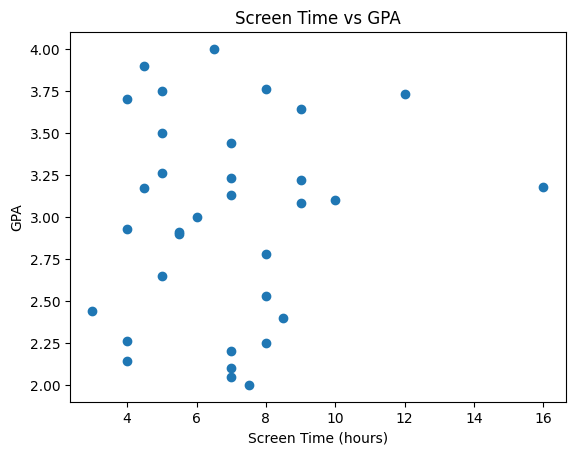

             gpa    screen     sleep     study
gpa     1.000000  0.104564 -0.192079  0.308370
screen  0.104564  1.000000 -0.172914  0.383889
sleep  -0.192079 -0.172914  1.000000 -0.185806
study   0.308370  0.383889 -0.185806  1.000000


In [2]:
from google.colab import files
uploaded = files.upload()
import pandas as pd
import matplotlib.pyplot as plt
import re

df = pd.read_csv("Untitled form.csv")


gpa_col = "What is your current GPA?\n(Please enter as a number, e.g., 3.25)"
screen_col = "On average, how many hours do you spend on screens daily?\n(Include phone, computer, tablet, etc.)"
sleep_col = "  On average, how many hours do you sleep per night?  "
study_col = "  On average, how many hours do you study per day outside of classes?  "

def clean(x):
    x = str(x).strip().lower()
    nums = re.findall(r"\d+\.?\d*", x)
    if len(nums) >= 2:
        return (float(nums[0]) + float(nums[1])) / 2
    elif len(nums) == 1:
        return float(nums[0])
    return None

df["gpa"] = df[gpa_col].apply(clean)
df["screen"] = df[screen_col].apply(clean)
df["sleep"] = df[sleep_col].apply(clean)
df["study"] = df[study_col].apply(clean)


df = df[(df["gpa"] >= 0) & (df["gpa"] <= 4)]
df = df[(df["screen"] >= 0) & (df["screen"] <= 24)]


df = df.dropna()

plt.scatter(df["screen"], df["gpa"])
plt.xlabel("Screen Time (hours)")
plt.ylabel("GPA")
plt.title("Screen Time vs GPA")
plt.show()


print(df[["gpa", "screen", "sleep", "study"]].corr())

In [3]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

X = df[["screen", "study", "sleep"]]
y = df["gpa"]

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

print("Coefficients:")
print("Screen Time:", model.coef_[0])
print("Study Time:", model.coef_[1])
print("Sleep Duration:", model.coef_[2])

print("\nModel Performance:")
print("MSE:", mean_squared_error(y, y_pred))
print("R2 Score:", r2_score(y, y_pred))

sample = [[6, 3, 7]]
prediction = model.predict(sample)

print("\nExample Prediction")
print("For 6 hours screen time, 3 hours study time, and 7 hours sleep:")
print("Predicted GPA:", prediction[0])

Coefficients:
Screen Time: -0.00757336934898034
Study Time: 0.10269033241539707
Sleep Duration: -0.0710290241600501

Model Performance:
MSE: 0.3048897564401875
R2 Score: 0.11483855078135174

Example Prediction
For 6 hours screen time, 3 hours study time, and 7 hours sleep:
Predicted GPA: 3.0083706959038707


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


## Machine Learning Model

For the machine learning part, I used a simple linear regression model to predict GPA based on screen time, study time, and sleep duration.

The model uses these three variables as inputs and GPA as the output. The coefficients show how each variable is related to GPA. Based on the results, study time appears to have a stronger relationship with GPA compared to screen time.

An example prediction was also made using 6 hours of screen time, 3 hours of study time, and 7 hours of sleep.